# Edge-ML Data Processing and Feature Engineering
This notebook loads datasets from Edge-ML, filters and preprocesses accelerator data (including trimming transitional pocket movements), applies rolling-window aggregations to extract statistical features, and visualizes the structured metrics across multiple axes.

### 1. Import Libraries and Load Environment Variables

In [1]:
import os 
from dotenv import load_dotenv
from edgeml import DatasetReceiver, Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# # Get API Keys
load_dotenv()
write_key = os.getenv("EDGE_WRITE_KEY")
read_key = os.getenv("EDGE_READ_KEY")

### 2. Initialize Edge-ML Receiver

In [2]:
# Uses Read- and Write-Key!
receiver = DatasetReceiver(
    backendURL="https://app.edge-ml.org",
    readKey=read_key,
    writeKey=write_key
)

receiver25 = DatasetReceiver(
  backendURL='https://beta.edge-ml.org',
  readKey='02a4fad735d3308b68672ddb7593f047',
  writeKey='5fe6e50c3fb5001531bbd8e03a8c591f'
)


### 3. Helper Functions for Dataset Discovery and Querying

In [3]:
# Gather all Datasets that have a certain name
def gather(datasets: list[Dataset], name: str):
    return [ds for ds in datasets if name.lower().startswith(getName(ds))]

def getParticipant(ds: Dataset):
    participant = ds.metaData.get("participantId") or ds.metaData.get("participant")
    return participant if participant is not None else None
    
def getWithParticipant(datasets: list[Dataset]): # type: ignore
    return [ds for ds in datasets if getParticipant(ds) != None]

# Gather own Datasets that have a certain name
def gatherOwn(datasets: list[Dataset], name: str):
    return [ds for ds in getOwn(datasets=datasets) if getName(ds) == name]    

# Get the label of the dataset (e.g. "swimming")
def getName(ds: Dataset):
    if ds.labelings == [] or ds.labelings == None:
        return ""
    return ds.labelings[0].labels[-1].name.lower()

# Get the dataset that I have created
def getOwn(datasets: list[Dataset]):
    return [ds for ds in datasets if ds.name.startswith("uoihp")]    

### 4. Fetch Label-Specific Datasets

In [ ]:
datasets26 = receiver.datasets
datasets25 = receiver25.datasets

datasets = datasets25 + datasets26

datasets_with_participant = getWithParticipant(datasets=datasets) 
print(f"Number of datasets: {len(datasets)}")
print(f"Number of datasets with pariticapant metadata: {len(datasets_with_participant)}")

# sitting
sitting_ds = gather(datasets_with_participant, "sitting")
print(f"Number of datasets with sitting: {len(sitting_ds)}")

walking_ds = gather(datasets_with_participant, "walking")
print(f"Number of datasets with walking: {len(walking_ds)}")

running_ds = gather(datasets_with_participant, "running")
print(f"Number of datasets with running: {len(running_ds)}")

stairs_ds  = gather(datasets_with_participant, "stairs")
print(f"Number of datasets with stairs: {len(stairs_ds)}")

standing_ds  = gather(datasets_with_participant, "standing")
print(f"Number of datasets with standing: {len(standing_ds)}")

participant_label = {}

def mapParticipant(datasets: list[Dataset], participant_label: dict[str, int]):
  for ds in datasets:
    participant = getParticipant(ds)
    if participant not in participant_label:
      participant_label[participant] = len(participant_label)

mapParticipant(sitting_ds, participant_label)
mapParticipant(walking_ds, participant_label)
mapParticipant(running_ds, participant_label)
mapParticipant(stairs_ds, participant_label)
mapParticipant(standing_ds, participant_label)

print(participant_label)

Number of datasets: 746
Number of datasets with pariticapant metadata: 431
Number of datasets with sitting: 210
Number of datasets with walking: 218
Number of datasets with running: 142
Number of datasets with stairs: 136
Number of datasets with standing: 163
{'10d83': 0, '11416': 1, '1a045': 2, '18053': 3, '144ca': 4, '1c6f5': 5, '1a3c3': 6, '17e1d': 7, '1929c': 8, '15b85': 9, '191d4': 10, '1f683': 11, '17dcc': 12, '18582': 13, '1dd54': 14, '11cc1': 15, '16742': 16, '1b728': 17, 'uspgb': 18, '12f77': 19, '1b682': 20, '1b949': 21, 'uupiw': 22, '1e60e': 23, '59fe': 24, '0cac': 25, 'vand': 26, 'Vand': 27, 'e5af': 28, 'bb8e': 29, '63fb': 30, '17f8': 31, '3f1d': 32, 'e7bd': 33, '5231': 34, '27f2': 35, '4e1c': 36, 'd470': 37, '6b5f': 38, 'a397': 39, '820e': 40, 'f825': 41, '077a': 42, '2351': 43, 'bbe0': 44, 'af6d': 45, 'ccb8': 46, '7806': 47, '8708': 48, '41ba': 49, 'e3b5': 50, '0ef5': 51, '8ea9': 52, '56db': 53, 'd0df': 54, 'ebf9': 55, 'a9a3': 56, '1926': 57, 'a25a': 58, '2080': 59, '904d

### 5. Data Transformation and Edge Trimming Functions

In [7]:
# Resample data because of different sample rates
# Convert datasets into one dataframe per activity
import numpy as np
import pandas as pd

def csv_dfs_to_df_with_trimmed_edges(df_list, activity_list):
    frames = []

    for (original_df, activity) in zip(df_list, activity_list):
        # Create a copy so we don't accidentally modify the original variable
        df = original_df.copy()

        # Ensure the columns match your required features
        df = df[
            ["time", "sensor_accX", "sensor_accY", "sensor_accZ", "subject"]
        ]

        df = df.rename(columns={
            "sensor_accX": "accX",
            "sensor_accY": "accY",
            "sensor_accZ": "accZ"
        })

        df = df.rename(columns={
            "sensor_acceleration.x": "accX",
            "sensor_acceleration.y": "accY",
            "sensor_acceleration.z": "accZ"
        })

        # add new feature
        # 3D acceleration amplitude
        # ---------------------------------- 
        df["accM"] = np.sqrt(
            df["accX"]**2 + 
            df["accY"]**2 + 
            df["accZ"]**2
        )
        # ---------------------------------- 


        df["time"] = pd.to_datetime(df["time"], unit="ms")
        
        df = df.sort_values("time")        
        start_time = df["time"].min() + pd.Timedelta(seconds=2)
        end_time = df["time"].max() - pd.Timedelta(seconds=2)
        
        # Keep only the data in the middle
        df = df[(df["time"] >= start_time) & (df["time"] <= end_time)]

        df["activity"] = activity
        frames.append(df)

    return pd.concat(frames, ignore_index=True)

def datasets_to_df_with_trimmed_edges(datasets: list[Dataset], activity: str, participant_label):
    frames = []

    for ds in datasets:
        # Create a copy so we don't accidentally modify the original variable
        ds.loadData()
        df = pd.DataFrame(ds.data)


        try:
            # Find which set of columns actually exists in this dataset
            if all(col in df.columns for col in ["accX", "accY", "accZ"]):
                acc_cols = ["accX", "accY", "accZ"]
            elif all(col in df.columns for col in ["acceleration.x", "acceleration.y", "acceleration.z"]):
                acc_cols = ["acceleration.x", "acceleration.y", "acceleration.z"]
            elif all(col in df.columns for col in ["sensor_acc_X", "sensor_acc_Y", "sensor_acc_Z"]):
                acc_cols = ["acc_X", "acc_Y", "acc_Z"]
            else:
                raise KeyError(f"Could not find a matching accelerometer column format in this dataset.\n DataFrame: {df}")

            # Ensure the columns match your required features
            df = df[["time"] + acc_cols]

            df = df.rename(columns={
                "sensor_accX": "accX",
                "sensor_accY": "accY",
                "sensor_accZ": "accZ"
            })

            df = df.rename(columns={
                "acceleration.x": "accX",
                "acceleration.y": "accY",
                "acceleration.z": "accZ"
            })

            df = df.rename(columns={
                "acc_X": "accX",
                "acc_Y": "accY",
                "acc_Z": "accZ"
            })

            # add new feature
            # 3D acceleration amplitude
            # ---------------------------------- 
            df["accM"] = np.sqrt(
                df["accX"]**2 + 
                df["accY"]**2 + 
                df["accZ"]**2
            )
            # ---------------------------------- 


            df["time"] = pd.to_datetime(df["time"], unit="ms")
            
            df = df.sort_values("time")        
            start_time = df["time"].min() + pd.Timedelta(seconds=2)
            end_time = df["time"].max() - pd.Timedelta(seconds=2)
            
            # Keep only the data in the middle
            df = df[(df["time"] >= start_time) & (df["time"] <= end_time)]

            df["activity"] = activity
            df["subject"]  = participant_label[getParticipant(ds)]
            frames.append(df)
        
        finally:
            continue

    return pd.concat(frames, ignore_index=True)

In [12]:
sitting_df = datasets_to_df_with_trimmed_edges(sitting_ds, "sitting", participant_label).dropna()
walking_df = datasets_to_df_with_trimmed_edges(walking_ds, "walking", participant_label).dropna()
running_df = datasets_to_df_with_trimmed_edges(running_ds, "running", participant_label).dropna()
stairs_df = datasets_to_df_with_trimmed_edges(stairs_ds, "stairs",  participant_label).dropna()
standing_df = datasets_to_df_with_trimmed_edges(standing_ds, "standing",  participant_label).dropna()

df = pd.concat([sitting_df, walking_df, running_df, stairs_df, standing_df], ignore_index=True)

/tmp/ipykernel_121398/3497454717.py:123: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(frames, ignore_index=True)
/tmp/ipykernel_121398/3497454717.py:123: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(frames, ignore_index=True)
/tmp/ipykernel_121398/3497454717.py:123: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the resu

### 6. Process Activity Data and Concatenate

In [13]:
print("Combined Dataset Info:")
print(df.info())
print("\nLabel Breakdown:")
print(df["activity"].value_counts())

print(df.head())


Combined Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 695840 entries, 0 to 695839
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   time      695840 non-null  datetime64[ns]
 1   accX      695840 non-null  float32       
 2   accY      695840 non-null  float32       
 3   accZ      695840 non-null  float32       
 4   accM      695840 non-null  float32       
 5   activity  695840 non-null  object        
 6   subject   695840 non-null  int64         
dtypes: datetime64[ns](1), float32(4), int64(1), object(1)
memory usage: 26.5+ MB
None

Label Breakdown:
activity
walking     194831
sitting     181825
running     112197
standing    103726
stairs      103261
Name: count, dtype: int64
                     time  accX  accY  accZ      accM activity  subject
0 2025-06-03 12:01:24.932  -0.1   0.1   0.0  0.141421  sitting        0
1 2025-06-03 12:01:24.949   0.0   0.0   0.0  0.000000  sitting   

### 7. Feature Extraction Using Rolling Windows

In [14]:
# 1. Set the time as the index and sort it chronologically
df_sorted = df.set_index("time").sort_index()

# 2. Group by activity, apply the rolling window, and aggregate
df_windowed = (
    df_sorted.groupby(["activity", "subject"])
      .rolling(window="1s")  # 'on="time"' is no longer needed since it's the index
      .agg(["mean", "std"])
      .dropna()
      .reset_index()          # Brings 'activity' and 'time' back as normal columns
)

# 3. Clean up MultiIndex column names (e.g., 'accX_mean')
df_windowed.columns = [
    f"{col[0]}_{col[1]}" if isinstance(col, tuple) and col[1] else col[0]
    for col in df_windowed.columns
 ]


df_windowed

,activity,subject,time,accX_mean,accX_std,accY_mean,accY_std,accZ_mean,accZ_std,accM_mean,accM_std
0,running,0,2025-06-03 12:03:09.888,-0.650000,0.070711,-0.300000,0.141421,-0.400000,0.000000,0.827642,0.004272
1,running,0,2025-06-03 12:03:09.904,-0.600000,0.100000,-0.233333,0.152753,-0.400000,0.000000,0.767786,0.103717
2,running,0,2025-06-03 12:03:09.920,-0.500000,0.216025,-0.225000,0.125831,-0.350000,0.100000,0.662442,0.227070
3,running,0,2025-06-03 12:03:09.938,-0.420000,0.258844,-0.220000,0.109545,-0.280000,0.178885,0.574675,0.277824
4,running,0,2025-06-03 12:03:09.954,-0.316667,0.343026,-0.200000,0.109545,-0.233333,0.196638,0.516164,0.286863
...,...,...,...,...,...,...,...,...,...,...,...
695406,walking,134,2026-06-20 22:24:22.764,3.993220,3.924321,-4.923729,4.419601,2.259322,6.179642,10.583949,2.290012
695407,walking,134,2026-06-20 22:24:22.780,3.946667,3.907597,-4.946667,4.385588,2.221667,6.133987,10.514438,2.333491
695408,walking,134,2026-06-20 22:24:22.797,4.144068,3.714801,-4.949153,4.424282,2.483051,5.950345,10.474570,2.414540
695409,walking,134,2026-06-20 22:24:22.814,4.254237,3.530767,-4.954237,4.425098,2.579661,5.835586,10.403846,2.478560


### 8. Prepare Data for Multi-axis Visualization

In [15]:
# 1. Melt the dataframe to long-form
df_melted = df_windowed.melt(
    id_vars=["activity", "time", "subject"],
    value_vars=[
        "accX_mean", "accX_std",
        "accY_mean", "accY_std",
        "accZ_mean", "accZ_std",
        "accM_mean", "accM_std"
    ],
    var_name="Sensor_Metric",
    value_name="Value"
)

# 2. Split the names into separate 'Axis' and 'Metric' columns
df_melted["Axis"] = df_melted["Sensor_Metric"].apply(lambda x: x.split("_")[0].replace("acc", ""))
df_melted["Metric"] = df_melted["Sensor_Metric"].apply(lambda x: x.split("_")[1])

# Check right now if 'Metric' actually exists and has data
print(df_melted.head())


  activity                    time  subject Sensor_Metric     Value Axis  \
0  running 2025-06-03 12:03:09.888        0     accX_mean -0.650000    X   
1  running 2025-06-03 12:03:09.904        0     accX_mean -0.600000    X   
2  running 2025-06-03 12:03:09.920        0     accX_mean -0.500000    X   
3  running 2025-06-03 12:03:09.938        0     accX_mean -0.420000    X   
4  running 2025-06-03 12:03:09.954        0     accX_mean -0.316667    X   

  Metric  
0   mean  
1   mean  
2   mean  
3   mean  
4   mean  


### 9. Plot Structural Metrics Matrix

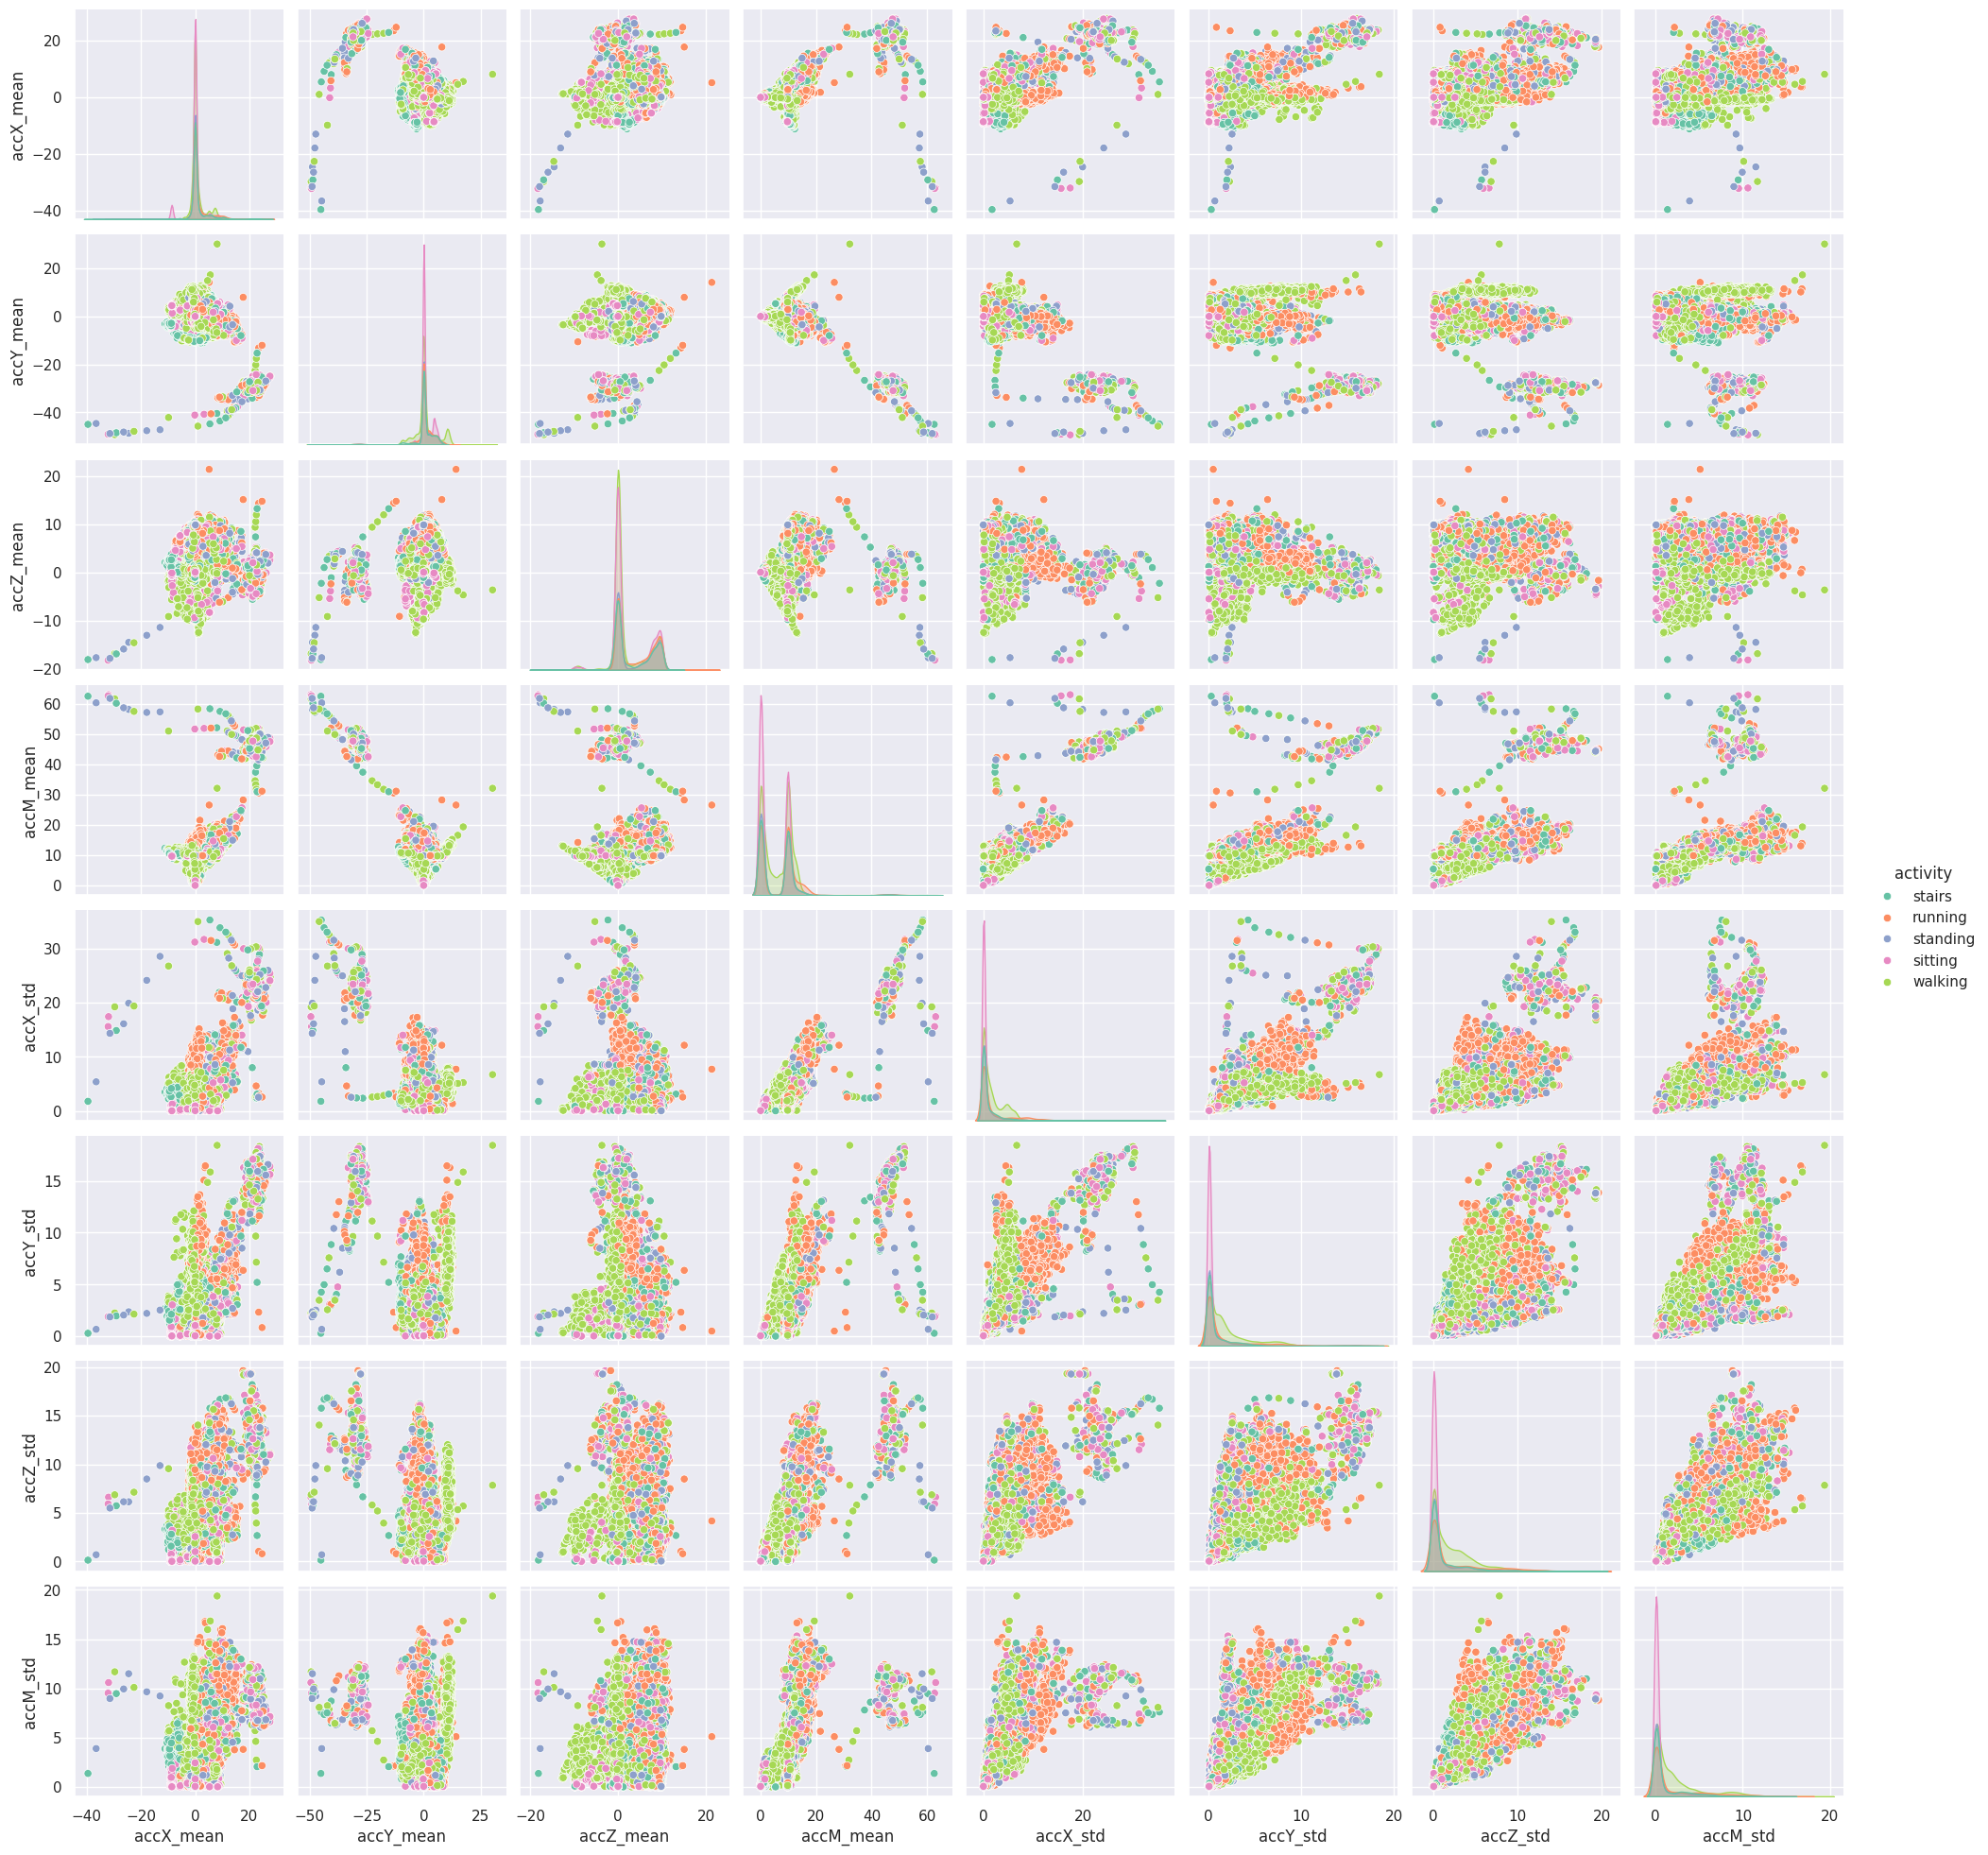

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only the feature columns you want to compare + the activity label
# (We completely leave out the 'time' column here)
feature_cols = [
    "accX_mean", "accY_mean", "accZ_mean", "accM_mean",
    "accX_std", "accY_std", "accZ_std", "accM_std",
    "activity"
]

df_features = df_windowed[feature_cols]

df_small = df_windowed.sample(frac=0.15, random_state=42)
df_small_features = df_small[feature_cols]

feature_cols = [
    "accX_mean", "accY_mean", "accZ_mean", "accM_mean",
    "accX_std", "accY_std", "accZ_std", "accM_std"
]

# 2. Set the theme
sns.set_theme(style="darkgrid")

# 3. Create the pairplot matrix
# 'hue' colors the points by sitting, walking, stairs
# 'kind="scatter"' ensures they show up as independent data points
g = sns.pairplot(
    data=df_small_features,
    vars=feature_cols,
    hue="activity", 
    kind="scatter",
    diag_kind="kde", # Shows the distribution curves on the diagonal
    palette="Set2"
)

# 4. Save and show
plt.savefig("feature_plot.png")
plt.show()

### 10. Train Models

In [18]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.model_selection import LeaveOneGroupOut, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier


# SMALL DATA BECAUSE BIG DATA TAKES TOO LONG RIGHT NOW
# df_windowed = df_small

X = df_windowed[feature_cols].values

groups = df_windowed["subject"].values  # Tracking array for subjects

# Encode our text labels ('walking', 'sitting'...) to 0, 1, 2
le = LabelEncoder()
y = le.fit_transform(df_windowed["activity"])

names = [
    # "Nearest Neighbors",
    # "Linear SVM",
    # "RBF SVM",
    # "Decision Tree",
    # Decided to use random forest
    "Random Forest",
    # "Neural Net",
    # "AdaBoost",
    # "Naive Bayes",
]

classifiers = [
    # KNeighborsClassifier(3),
    # SVC(kernel="linear", C=0.025, random_state=42),
    # SVC(gamma=2, C=1, random_state=42),
    # DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(
        max_depth=3, n_estimators=10, max_features=5, random_state=42
    ),
    # MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    # AdaBoostClassifier(random_state=42),
    # GaussianNB(),
]

classifiers = list(zip(names, classifiers))

for c in classifiers:
    print("-----------------------------")
    print(f"{c[0]}:")
    print("-----------------------------")
    cvs = cross_val_score(c[1], X, y, groups=groups, cv=LeaveOneGroupOut(), scoring="f1_macro")
    print(f"F1-Score: {cvs.mean()}")

-----------------------------
Random Forest:
-----------------------------
F1-Score: 0.3479691554731643


### 11. PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

for c in classifiers:
    print("-----------------------------")
    print(f"{c[0]}:")
    print("-----------------------------")
    cvs = cross_val_score(c[1], X_pca, y, groups=groups, cv=LeaveOneGroupOut(), scoring="f1_macro")
    print(f"F1-Score: {cvs.mean()}")


-----------------------------
Random Forest:
-----------------------------
F1-Score: 0.44139601212660945


### 12. RFE

In [ ]:
from sklearn.feature_selection import RFE


names = [
    # "Linear SVM",
    # "Decision Tree",
    "Random Forest",
    # "AdaBoost",
]

models = [
    # SVC(kernel="linear", C=0.025, random_state=42),
    # DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=5, random_state=42),
    # AdaBoostClassifier(random_state=42),
]

# 1. First, pair them into your list of tuples
classifiers = list(zip(names, models))

feature_cols_arr = np.array(feature_cols)

for c in classifiers:
    rf = c[1]

    rfe = RFE(
        estimator=rf,
        n_features_to_select=4
    )

    rfe.fit(X, y)


    selected_features = feature_cols_arr[rfe.support_]

    X_rfe = df_windowed[selected_features].values 

    print("-----------------------------")
    print(f"{c[0]}:")
    print("-----------------------------")
    cvs = cross_val_score(c[1], X_rfe, y, groups=groups, cv=LeaveOneGroupOut(), scoring="f1_macro")
    print(f"F1-Score: {cvs.mean()}")

    print("Selected features:")
    print(selected_features)


-----------------------------
Random Forest:
-----------------------------
F1-Score: 0.4459962321083768
Selected features:
['accY_mean' 'accZ_mean' 'accX_std' 'accM_std']


### 14. Bayesian Optimization

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

# Kernel allows to make bigger steps than the default kernel
# Just necessary because i set the max to 128 for fun ;)
kernel = Matern(length_scale=20.0, length_scale_bounds=(2.0, 100.0), nu=2.5)

gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True, n_restarts_optimizer=5)

# Declare Hyperparameter range
X_opt = np.arange(start=1, stop=129, step=1).reshape(-1, 1)

# Keep track of hyperparameter to score
X_score = []

# Hyperparameters
X_bo = []

# Scores
y_bo = []

# initialize first choice of hyperparameter
x_next = 3

for _ in range(10):
  # Add Hyperparameter
  X_bo.append([x_next])

  # Define Model
  clf = RandomForestClassifier(max_depth=5, n_estimators=x_next, max_features=5, random_state=42)
  # Train and Validate Model 
  cvs = cross_val_score(clf, X, y, groups=groups, cv=LeaveOneGroupOut(), scoring="f1_macro")
  # Get score of the model (y^)
  score = cvs.mean()

  # Add learned Data 
  y_bo.append(score)

  X_score.append((x_next, score))

  # Fit known hyperparameters to find the next (most unknown) hyperparameter
  gpr.fit(X_bo, y_bo)

  # Calculate next highest probability to look at
  mean_pred, std_pred = gpr.predict(X_opt, return_std=True)

  # A kappa of 2.0 or 3.0 is a good balance for exploration
  kappa = 2.5
  ucb_score = mean_pred + kappa * std_pred

  best_idx = ucb_score.argmax()
  x_next = int(X_opt[best_idx][0])


for (x, score) in X_score:
  print(f"n_estimators {x}: {score}")




KeyboardInterrupt: 

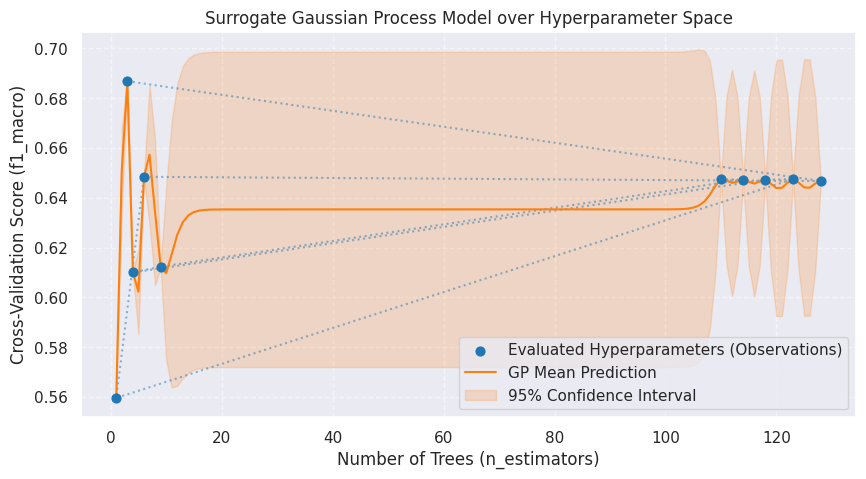

In [ ]:
import matplotlib.pyplot as plt

# 1. Generate predictions over your entire hyperparameter search space
mean_pred, std_pred = gpr.predict(X_opt, return_std=True)

# Flatten your collected search points so matplotlib can plot them
x_observed = np.array(X_bo).ravel()
y_observed = np.array(y_bo)

plt.figure(figsize=(10, 5))

# Plot your actual cross-validation history points
plt.scatter(
    x_observed,
    y_observed,
    color="tab:blue",
    marker="o",
    s=40,
    zorder=5,
    label="Evaluated Hyperparameters (Observations)",
)

# Connect them chronologically with a light dotted line to see the search path
plt.plot(x_observed, y_observed, linestyle="dotted", color="tab:blue", alpha=0.5)

# Plot the surrogate model's predicted performance mean curve
plt.plot(X_opt.ravel(), mean_pred, color="tab:orange", label="GP Mean Prediction")

# Shaded 95% Confidence Interval region (Mean +/- 1.96 * Std Dev)
plt.fill_between(
    X_opt.ravel(),
    mean_pred - 1.96 * std_pred,
    mean_pred + 1.96 * std_pred,
    color="tab:orange",
    alpha=0.2,
    label="95% Confidence Interval",
)

plt.legend()
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Cross-Validation Score (f1_macro)")
plt.title("Surrogate Gaussian Process Model over Hyperparameter Space")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [24]:
import optuna
from optuna.samplers import RandomSampler, GPSampler, GridSampler, QMCSampler, BruteForceSampler
import warnings
import optuna
from sklearn.model_selection import GroupKFold

optuna.logging.set_verbosity(optuna.logging.ERROR)

warnings.filterwarnings("ignore")

def objective(trial):
  n_estimators = trial.suggest_int("n_estimators", 1, 64)
  max_depth = trial.suggest_int("max_depth", 1, 10)
  max_features = trial.suggest_int("max_features", 1, 6)

  clf = RandomForestClassifier(max_depth=max_depth, n_estimators=n_estimators, max_features=max_features, random_state=42)
  cvs = cross_val_score(clf, X, y, groups=groups, cv=GroupKFold(n_splits=5), scoring="f1_macro")

  return cvs.mean()

In [25]:
rs  = RandomSampler(seed=42)

sampler = rs
study = optuna.create_study(sampler=sampler, direction="maximize")
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
print("Best value: ", best_trial.value)
print("Parameters that achieve the best value: ", best_trial.params)



KeyboardInterrupt: 

In [22]:
gp  = GPSampler(seed=42)

sampler = gp
study = optuna.create_study(sampler=sampler, direction="maximize")
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
print("Best value: ", best_trial.value)
print("Parameters that achieve the best value: ", best_trial.params)

KeyboardInterrupt: 

In [ ]:
gd  = GridSampler(
  search_space={
    "n_estimators": [1, 32, 64],
    "max_depth": [1, 5, 10],
    "max_features": [1, 3, 6]
  },
  seed=42
)

sampler = gd
study = optuna.create_study(sampler=sampler, direction="maximize")
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
print("Best value: ", best_trial.value)
print("Parameters that achieve the best value: ", best_trial.params)

Best value:  0.7192025430960892
Parameters that achieve the best value:  {'n_estimators': 32, 'max_depth': 10, 'max_features': 1}


In [10]:
qmc = QMCSampler(seed=42)

sampler = qmc
study = optuna.create_study(sampler=sampler, direction="maximize")
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
print("Best value: ", best_trial.value)
print("Parameters that achieve the best value: ", best_trial.params)

NameError: name 'QMCSampler' is not defined

In [ ]:
bf  = BruteForceSampler(seed=42)

sampler = bf
study = optuna.create_study(sampler=sampler, direction="maximize")
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
print("Best value: ", best_trial.value)
print("Parameters that achieve the best value: ", best_trial.params)

Best value:  0.7293836268597125
Parameters that achieve the best value:  {'n_estimators': 30, 'max_depth': 6, 'max_features': 1}


In [24]:
print(X.shape[1])

8


In [ ]:
from skl2onnx import convert_sklearn
import torch
import torch.nn as nn
import onnx
from skl2onnx.common.data_types import FloatTensorType

TARGET_OPSET = 17

# Parameters that achieve the best value:  {'n_estimators': 31, 'max_depth': 6, 'max_features': 1}
rf = RandomForestClassifier(
  n_estimators=31,
  max_depth=6,
  max_features=1,
  random_state=42
)

rf.fit(X, y)

num_features = X.shape[1]
initial_type = [('extracted_features', FloatTensorType([None, num_features]))]

rf_onnx = convert_sklearn(
    rf,
    initial_types=initial_type,
    target_opset=TARGET_OPSET
)

# 1. Define PyTorch Math Preprocessor
class SignalPreprocessingGraph(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # x shape: (1, 3, N) -> [accX, accY, accZ] over time
        accX = x[:, 0, :]
        accY = x[:, 1, :]
        accZ = x[:, 2, :]

        accM = torch.sqrt(accX**2 + accY**2 + accZ**2)

        accX_mean = torch.mean(accX, dim=1, keepdim=True)
        accY_mean = torch.mean(accY, dim=1, keepdim=True)
        accZ_mean = torch.mean(accZ, dim=1, keepdim=True)
        accM_mean = torch.mean(accM, dim=1, keepdim=True)

        accX_std = torch.std(accX, dim=1, keepdim=True, correction=0)
        accY_std = torch.std(accY, dim=1, keepdim=True, correction=0)
        accZ_std = torch.std(accZ, dim=1, keepdim=True, correction=0)
        accM_std = torch.std(accM, dim=1, keepdim=True, correction=0)

        features = torch.cat([
            accX_mean, accY_mean, accZ_mean, accM_mean,
            accX_std,  accY_std,  accZ_std,  accM_std
        ], dim=1)
        
        return features

prep_graph = SignalPreprocessingGraph().eval()
dummy_sensor_input = torch.randn(1, 3, 50)

torch.onnx.export(
    prep_graph,
    dummy_sensor_input,
    "prep_graph.onnx",
    input_names=["raw_sensor_data"],
    output_names=["extracted_features"],
    dynamic_axes={"raw_sensor_data": {2: "num_samples"}},
    opset_version=TARGET_OPSET,
    dynamo=False   # important
)

prep_onnx_model = onnx.load("prep_graph.onnx")
rf_onnx_model = onnx.load_from_string(rf_onnx.SerializeToString())

# Make IR versions identical
rf_onnx_model.ir_version = prep_onnx_model.ir_version

# Remove the opset conflict
# Keep the RF tree model's opsets
prep_onnx_model.opset_import.clear()

for opset in rf_onnx_model.opset_import:
    prep_onnx_model.opset_import.append(opset)

baked_model = onnx.compose.merge_models(
    prep_onnx_model,
    rf_onnx_model,
    io_map=[
        ("extracted_features", "extracted_features")
    ],
)

onnx.checker.check_model(baked_model)

onnx.save(
    baked_model,
    "sensor_classifier.onnx"
)

print("Successfully saved unified pipeline")

Successfully saved unified pipeline


/tmp/ipykernel_136621/2754590693.py:61: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [ ]:
import onnx

model = onnx.load("sensor_classifier.onnx")

for inp in model.graph.input:
    print(inp.name, inp.type.tensor_type.shape)

for out in model.graph.output:
    print("OUTPUT:", out.name)

raw_sensor_data dim {
  dim_value: 1
}
dim {
  dim_value: 3
}
dim {
  dim_param: "num_samples"
}

OUTPUT: output_label
OUTPUT: output_probability


In [28]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession("sensor_classifier.onnx")

x = np.random.randn(1, 3, 149).astype(np.float32)

outputs = session.run(
    None,
    {"raw_sensor_data": x}
)

print(outputs)

[array([3], dtype=int64), [{0: 0.0018023380544036627, 1: 0.4704323410987854, 2: 0.02284005656838417, 3: 0.5049252510070801}]]
